# 03 — Evaluation & Model Comparison

This notebook evaluates trained models on the NuminaMath-CoT test set and
provides a head-to-head comparison between the SFT and RL (GRPO) models.

**Metrics:** Exact-match accuracy on `\boxed{}` answers with symbolic equality fallback.

## 1. Setup

In [1]:
# Clone the repo (replace with your GitHub URL)
!git clone https://github.com/Roogard/math-rl-tuning.git
%cd math-rl-tuning

# Install the package
!pip install -e ".[viz]" --quiet
!pip install bitsandbytes latex2sympy2 --quiet
!pip install math-verify

Cloning into 'math-rl-tuning'...
remote: Enumerating objects: 397, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 397 (delta 20), reused 35 (delta 16), pack-reused 352 (from 1)
Receiving objects: 100% (397/397), 4.13 MiB | 15.56 MiB/s, done.
Resolving deltas: 100% (244/244), done.
/content/math-rl-tuning
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 52.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==

In [2]:
from math_rl_tuning.config import load_config
from math_rl_tuning.utils import setup_hf_token, mount_google_drive

cfg = load_config()
setup_hf_token()
mount_google_drive()

Mounted at /content/drive


## 2. Configure Model Paths

In [3]:
# Point these to your saved adapters (local or Google Drive)
#SFT_ADAPTER_PATH = cfg.paths.sft_output_dir
#RL_ADAPTER_PATH = cfg.paths.grpo_output_dir

# Or use Drive paths:
SFT_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/sft"
RL_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/grpo"

NUM_SAMPLES = 100  # Number of test examples to evaluate

## 3. Load Test Data

In [4]:
from math_rl_tuning.data import prepare_test_data

test_ds = prepare_test_data(cfg)
print(f"Test examples: {len(test_ds)}")
print(f"Sample problem: {test_ds[0]['problem'][:200]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

...

data/train-00004-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/859494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Test set size: 59
Test set sources: ['cn_k12', 'gsm8k', 'math', 'orca_math']
Test examples: 59
Sample problem: Given the function $f(x)=|x+1|-|x-2|$.
$(1)$ Find the solution set of the inequality $f(x)\geqslant 1$;
$(2)$ If the solution set of the inequality $f(x)\geqslant x^{2}-x+m$ is non-empty, find the ran...


## 4. Evaluate a Single Model

Use this to evaluate just one model (SFT or RL).

In [6]:
from math_rl_tuning.evaluation import evaluate_adapter

sft_df, sft_acc = evaluate_adapter(
    adapter_path=SFT_ADAPTER_PATH,
    test_dataset=test_ds,
    cfg=cfg,
    num_samples=NUM_SAMPLES,
    model_name="SFT",
)

print(f"\nSFT Accuracy: {sft_acc:.2%}")
sft_df.head(10)


Loading adapter: /content/drive/MyDrive/math-rl-tuning/sft


KeyboardInterrupt: 

## 5. Head-to-Head Comparison (Base vs SFT vs RL)

In [7]:
from math_rl_tuning.evaluation import compare_models, save_results

results = compare_models(
    sft_adapter_path=SFT_ADAPTER_PATH,
    rl_adapter_path=RL_ADAPTER_PATH,
    test_dataset=test_ds,
    cfg=cfg,
    num_samples=NUM_SAMPLES,
)

# Save results to disk
save_results(results, cfg.paths.eval_output_dir)

  HEAD-TO-HEAD MODEL COMPARISON

Loading base model: Qwen/Qwen2.5-7B-Instruct
Loading tokenizer: Qwen/Qwen2.5-7B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

SFT Accuracy: 0.3400  (17/50)

Loading RL adapter: /content/drive/MyDrive/math-rl-tuning/grpo


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Evaluating RL (GRPO) on 50 examples (batch_size=16)...


Batches: 100%|██████████| 4/4 [13:07<00:00, 196.92s/it]


RL (GRPO) Accuracy: 0.3800  (19/50)
Memory cleared.

  RESULTS
Base Accuracy:      38.00%
SFT Accuracy:       34.00%  (-4.00% vs Base)
RL (GRPO) Accuracy: 38.00%  (+4.00% vs SFT)

SFT fixed 2 Base errors, regressed on 4.
RL fixed 4 SFT errors, regressed on 2.
Summary saved to: ./outputs/eval/summary.json
base_results saved to: ./outputs/eval/base_results.csv
sft_results saved to: ./outputs/eval/sft_results.csv
rl_results saved to: ./outputs/eval/rl_results.csv


## 6. Visualize Results

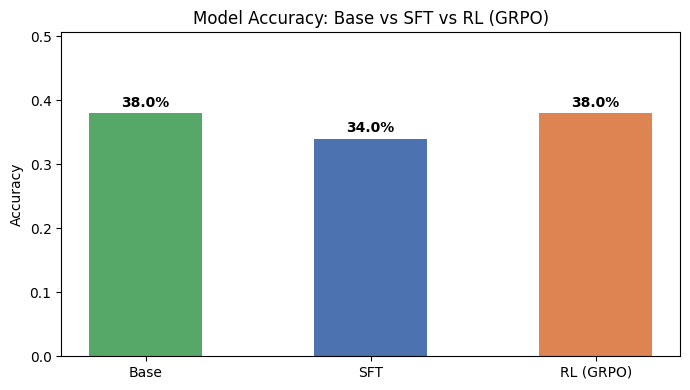

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Bar chart: accuracy comparison across all three models
fig, ax = plt.subplots(figsize=(7, 4))

model_labels = []
accuracies = []
colors = []

if "base_accuracy" in results:
    model_labels.append("Base")
    accuracies.append(results["base_accuracy"])
    colors.append("#55A868")

model_labels += ["SFT", "RL (GRPO)"]
accuracies += [results["sft_accuracy"], results["rl_accuracy"]]
colors += ["#4C72B0", "#DD8452"]

bars = ax.bar(model_labels, accuracies, color=colors, width=0.5)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy: Base vs SFT vs RL (GRPO)")
ax.set_ylim(0, max(accuracies) * 1.2 + 0.05)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.1%}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

In [9]:
def show_comparison(df, col_a, col_b, label_a, label_b):
    """Print cases where model B fixed model A's errors, and vice versa."""
    gains = df[(~df[f"{col_a}_correct"]) & df[f"{col_b}_correct"]]
    regressions = df[df[f"{col_a}_correct"] & (~df[f"{col_b}_correct"])]
    print(f"{label_b} fixed {len(gains)} {label_a} errors, regressed on {len(regressions)}.")
    if not gains.empty:
        print(f"\n=== {label_b} Improvements over {label_a} ===")
        display(gains[["problem_snippet", "ground_truth"]].reset_index(drop=True))

# Base → SFT
if "base_vs_sft" in results:
    print("── Base → SFT ──────────────────────────────")
    show_comparison(results["base_vs_sft"], "Base", "SFT", "Base", "SFT")

# SFT → RL
if "sft_vs_rl" in results:
    print("\n── SFT → RL ────────────────────────────────")
    show_comparison(results["sft_vs_rl"], "SFT", "RL", "SFT", "RL")

── Base → SFT ──────────────────────────────
SFT fixed 2 Base errors, regressed on 4.

=== SFT Improvements over Base ===


,problem_snippet,ground_truth
0,Billy worked for 3 straight hours on his homew...,3:1
1,Given that $α$ is an angle in the third quadra...,\frac{1}{2}



── SFT → RL ────────────────────────────────
RL fixed 4 SFT errors, regressed on 2.

=== RL Improvements over SFT ===


,problem_snippet,ground_truth
0,A bullet train 240 m long is running with a sp...,8
1,"In a community of 120 families, 25 families ow...",5
2,Given a sequence ${a_n}$ with the sum of its f...,768
3,Given the function $f(x)=|2x-1|$.\n(I) If the ...,4


## 7. Cleanup

In [10]:
from math_rl_tuning.utils import clean_memory
clean_memory()

Memory cleared.
